## Project Checkpoint 2: Research Question Formation

### A Project title：H&M Recommendation – (Checkpoint 2)

Collaboration declaration：
Collaborators:/
Web Sources:/
AI Tools:GPT

### B Project scope

Brief recap of dataset and EDA findings
- Dataset: H&M Kaggle（transactions_train.csv / customers.csv / articles.csv）
- EDA findings：long tail, item popularity drift, most baskets are small
- Course techniques:
  tf-idf
  item2vec/word2vec
- External techniques: item-cf
  

### C Data Loading + Basic Sanity Checks

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

path = 'data/'
art = f'{path}articles.csv'
cus = f'{path}customers.csv'
train = f'{path}transactions_train.csv'
sub = f'{path}sample_submission.csv'

In [3]:
df = pd.read_csv(train,dtype= {'customer_id':str, 'article_id':str}, parse_dates = ['t_dat'])
df.head(5)


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2


In [4]:
df.shape

(31788324, 5)

In [5]:
df_art = pd.read_csv(art,dtype = {'article_id':str})
df_art.shape


(105542, 25)

In [6]:
df_cus = pd.read_csv(cus,dtype= {'customer_id':str})
df_cus.shape

(1371980, 7)

### D Research Questions

RQ1: When representing each article using TF-IDF built from article metadata/text fields (e.g., product_type, department, index group, and/or description text), do TF-IDF cosine-similarity neighbors provide useful candidate expansions, and do they improve MAP@12 compared to popularity-only and co-occurrence baselines?

Data mining task type:
Content-based similarity mining / item-to-item retrieval (candidate generation)

Relevant algorithm(s):
TF-IDF vectorization (course) + cosine similarity retrieval (course/standard IR)

Evaluation criteria:

Representation / neighbor quality:

Neighbor coherence: overlap rate of product_type / department among top-K neighbors

Interpretability: top TF-IDF terms per item & qualitative neighbor examples

(Optional) Diversity: unique product_types in retrieved neighbors

Recommendation utility:

Candidate coverage (how many validation purchases are covered by TF-IDF candidates)

recall@12, MAP@12 (time-based validation)

Sensitivity:

Performance vs. vectorizer choices: max_features, min_df, n-gram range

Field ablation: which article fields contribute most (metadata-only vs. add text)

RQ2 (Course technique): item2vec / Word2Vec embeddings

RQ2: Can item2vec embeddings (Word2Vec trained on each customer’s time-ordered purchase sequence) generate more useful similar-item candidates than co-occurrence-based ItemCF, and does embedding-based recall increase MAP@12 when fused with popularity and/or CF candidates?

Data mining task type: Representation learning (embeddings) + Similarity-based candidate generation

Relevant algorithm(s): item2vec (Word2Vec Skip-gram/CBOW + negative sampling) (course if Word2Vec is taught; otherwise external)

Evaluation criteria:

Embedding neighbor quality: qualitative nearest-neighbor checks (interpretability), diversity/long-tail coverage

Recommendation utility: recall@12, MAP@12 (time-based validation), candidate coverage

Robustness: effect of embedding hyperparameters (dimension, window, min_count) on MAP@12

RQ3 (External technique): ItemCF / Item-based Collaborative Filtering
RQ3: When building an item-based collaborative filtering model from the user–item implicit interaction matrix, what item–item similarity structure emerges under different similarity/shrinkage settings, and do ItemCF-based candidate expansions improve MAP@12 compared to popularity-only and non-CF similarity methods (TF-IDF / item2vec)?

Data mining task type:
Collaborative filtering / item-to-item similarity mining (implicit feedback)

Relevant algorithm(s):
ItemCF (item–item KNN) using cosine similarity on a sparse user–item matrix
(Optional enhancements: shrinkage, time-decay weighting, top-K neighbor pruning)

Evaluation criteria:

Model/similarity quality: top neighbors sanity checks; (optional) category coherence among neighbors

Recommendation utility: candidate coverage, recall@12, MAP@12 (time-based validation)

Sensitivity: performance vs. top-K neighbors, shrinkage strength, time-decay weight, interaction definition (event-level vs. weekly)

Baselines:
Popularity-only; TF-IDF neighbors; item2vec neighbors; simple co-occurrence counts


## E RQ-to-Method Mapping Table 

| RQ | Course / External | Data mining task type | Data representation (input construction) | Relevant algorithm(s) | Key decisions to document (WHY) | Evaluation criteria (metrics) | Baselines / Controls | Outputs to report |
|---|---|---|---|---|---|---|---|---|
| **RQ1: TF-IDF Similarity Candidates**  *Using TF-IDF representations of articles built from metadata/text fields, do cosine-similarity neighbors yield useful candidate expansions and improve MAP@12 vs. popularity and simple co-occurrence? Which fields matter most?* | **Course**  | Content-based similarity / item-to-item retrieval (candidate generation) | Build an **item “pseudo-text”** from `articles` fields (e.g., `product_type_name`, `department_name`, `index_group_name`, optionally `prod_name`/`detail_desc` if available). Compute TF-IDF; retrieve top-K neighbors by cosine similarity. | **TF-IDF** (TfidfVectorizer) + **cosine similarity** retrieval | WHY choose fields included in pseudo-text (signal vs noise/missingness).  WHY `max_features`, `min_df`, n-grams (memory/overfit control).  \nWHY top-K neighbors and which user triggers (recent purchases). | **Neighbor quality:** category coherence among neighbors (same department/product_type rate), qualitative examples.  **Recommendation utility:** candidate coverage, recall@12, MAP@12 (time split).  **Sensitivity:** vectorizer params + field ablation. | Popularity-only.  Co-occurrence similarity.  (Optional) item2vec neighbors (if implemented).  Metadata-only vs. +text (ablation). | Example neighbor lists.  Ablation table (fields/params → MAP@12).  Coverage/recall@12/MAP@12 comparisons. |
| **RQ2: item2vec / Word2Vec Similarity**  \n*When training item2vec embeddings on customer purchase sequences (or customer-week baskets), what item neighborhoods and similarity structure emerge under different training choices, and do embedding-based candidate expansions improve MAP@12 vs. a popularity-only baseline?* | **Course** | Representation learning / similarity mining (item-to-item retrieval for candidate generation) | Build **training sequences** per customer by sorting purchases by `t_dat` (optionally collapse to customer-week tokens). Train embeddings on sequences; retrieve top-K nearest neighbors by cosine similarity for each recently purchased item. | **Word2Vec / item2vec** (Skip-gram or CBOW + negative sampling) + cosine similarity nearest-neighbor retrieval | WHY sequence definition (event-level vs customer-week) affects context quality.  \nWHY filtering/min\_count/top-K items (controls sparsity and training stability).  \nWHY embedding hyperparameters (window size, vector dim, negative samples) trade off generalization vs specificity.  \nWHY top-K neighbors per seed item (candidate size vs coverage). | **Embedding quality:** qualitative neighbor examples; category coherence among neighbors (same `product_type`/`department` rate).  \n**Recommendation utility:** candidate coverage, recall@12, MAP@12 (time-based validation).  \n**Sensitivity:** MAP@12 vs. key hyperparameters (window, dim, min\_count, epochs) and candidate K. | Popularity-only (global or recent).  \nSimple co-occurrence similarity (pair counts) as a non-embedding baseline. | Example nearest-neighbor lists + coherence stats.  \nCoverage/recall@12/MAP@12 comparisons.  \nHyperparameter sensitivity plot/table. |
| **RQ3: ItemCF (Item-based Collaborative Filtering)**  \n*Given the implicit user–item interaction data, can an ItemCF model (item–item similarity from co-interactions) generate higher-coverage and higher-MAP@12 candidate expansions than popularity-only and non-CF similarity methods (TF-IDF / item2vec)? How sensitive is performance to similarity construction choices?* | **External** | Collaborative filtering / item-to-item similarity mining (implicit feedback) | Build a sparse **user–item implicit interaction matrix** from `transactions_train` (optionally time-windowed). Compute **item–item similarities** (e.g., cosine on the interaction matrix, optionally with shrinkage/time-decay). For each user, use their **most recent N purchased items** as seeds and retrieve top-K similar items per seed; union + de-dup to form candidate set. | **ItemCF (item–item KNN)** using cosine similarity on implicit interactions  \n(Optional enhancements: shrinkage, time-decay weighting, top-K neighbor pruning) | WHY implicit interaction definition (event-level vs customer-week; include/exclude repeats).  \nWHY time window / recency weighting (concept drift and short-term intent).  \nWHY similarity choice + shrinkage (reduce noise for rare items).  \nWHY top-K neighbors per item and seed selection (coverage vs candidate size).  \nWHY filtering items/users (tractability and stability). | **Recommendation utility:** candidate coverage, recall@12, MAP@12 (time-based validation).  \n**Similarity sanity:** qualitative top neighbors; (optional) category coherence among neighbors.  \n**Sensitivity:** MAP@12 vs K-neighbors, shrinkage strength, time-decay, and seed-history length N.  \n**Efficiency:** build-time and memory vs item vocabulary size. | Popularity-only (global or recent).  \nTF-IDF neighbors (content-based).  \nitem2vec neighbors (embedding-based).  \nSimple co-occurrence counts (no normalization) as a lightweight CF baseline. | Coverage/recall@12/MAP@12 comparisons vs baselines.  \nExample item-neighbor lists + coherence stats.  \nSensitivity table/plot (K, shrinkage, time-decay). |

## F Additional EDA

(31788324, 5) (1371980, 7) (105542, 25)
Unique customers: 1362281
Unique articles: 104547


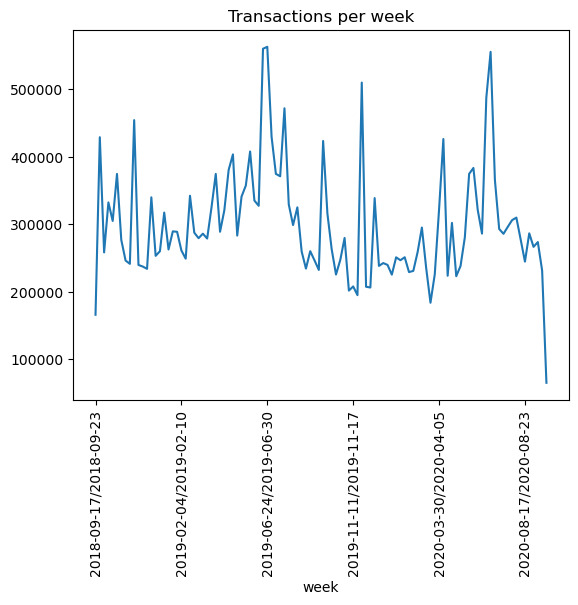

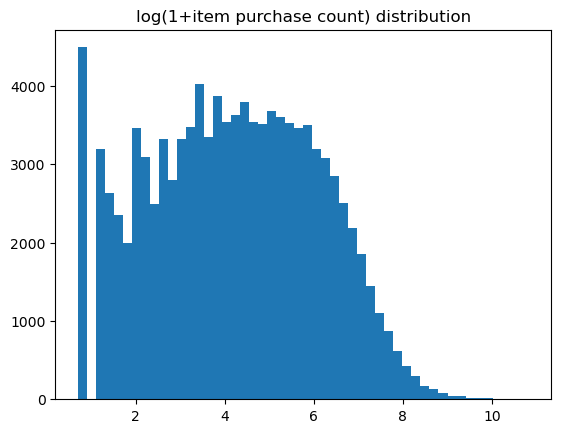

100 coverage: 0.04600906295028326
500 coverage: 0.12208281254463117
1000 coverage: 0.18159831263831336
5000 coverage: 0.43090632900306414
10000 coverage: 0.5959620582702001


In [7]:
#general
import  matplotlib.pyplot as plt
trans = df.copy()
cus = df_cus.copy()
art = df_art.copy()

# ---- Sanity checks
print(trans.shape, cus.shape, art.shape)
print("Unique customers:", trans["customer_id"].nunique())
print("Unique articles:", trans["article_id"].nunique())

# ---- Time EDA
trans["t_dat"] = pd.to_datetime(trans["t_dat"])
trans["week"] = trans["t_dat"].dt.to_period("W").astype(str)

weekly = trans.groupby("week").size()
plt.figure()
weekly.plot()
plt.title("Transactions per week")
plt.xticks(rotation=90)
plt.show()

# ---- Long-tail EDA
item_cnt = trans["article_id"].value_counts()
plt.figure()
plt.hist(np.log1p(item_cnt.values), bins=50)
plt.title("log(1+item purchase count) distribution")
plt.show()

def topk_coverage(k):
    return item_cnt.head(k).sum() / item_cnt.sum()

for k in [100, 500, 1000, 5000, 10000]:
    print(k, "coverage:", topk_coverage(k))

In [8]:
## TFIDF EDA
tfidf_fields = ["product_type_name","department_name","index_group_name","colour_group_name"]
art[tfidf_fields].isna().mean().sort_values(ascending=False)

product_type_name    0.0
department_name      0.0
index_group_name     0.0
colour_group_name    0.0
dtype: float64

In [9]:
art[tfidf_fields].nunique().sort_values(ascending = False)

department_name      250
product_type_name    131
colour_group_name     50
index_group_name       5
dtype: int64

In [10]:
art["pseudo_text"] = art[tfidf_fields].astype(str).agg(" ".join, axis=1)
tok_len = art["pseudo_text"].str.split().apply(len)
tok_len.describe()

count    105542.000000
mean          5.834483
std           1.262864
min           4.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          12.000000
Name: pseudo_text, dtype: float64

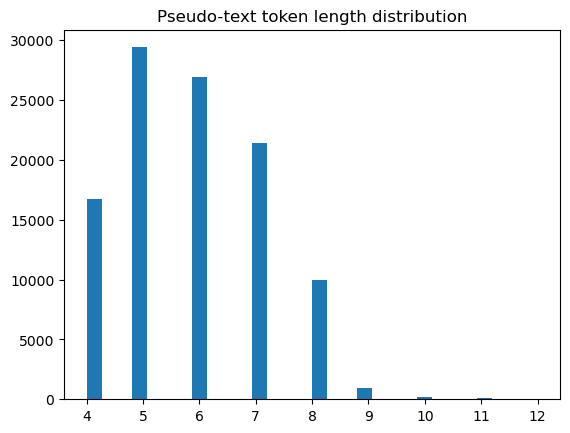

In [11]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(tok_len.values, bins=30)
plt.title("Pseudo-text token length distribution")
plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(min_df=5, max_features=200000)
X = vec.fit_transform(art["pseudo_text"])
print("TF-IDF shape:", X.shape)   # (n_items, vocab_size)

TF-IDF shape: (105542, 248)


In [13]:
art.head(5)

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,pseudo_text
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,Vest top Jersey Basic Ladieswear Black
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,Vest top Jersey Basic Ladieswear White
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,Vest top Jersey Basic Ladieswear Off White
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",Bra Clean Lingerie Ladieswear Black
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",Bra Clean Lingerie Ladieswear White


All selected metadata fields have 0% missingness, making them reliable inputs for building TF-IDF item representations.
The TF-IDF matrix has shape (105,542 items, 248 features), indicating a small and stable vocabulary derived from article metadata. This makes TF-IDF computation highly feasible and memory-efficient for candidate generation.

WHY:if some cols unique is very large, TFIDF will become very large, we have to use min_df or max_features

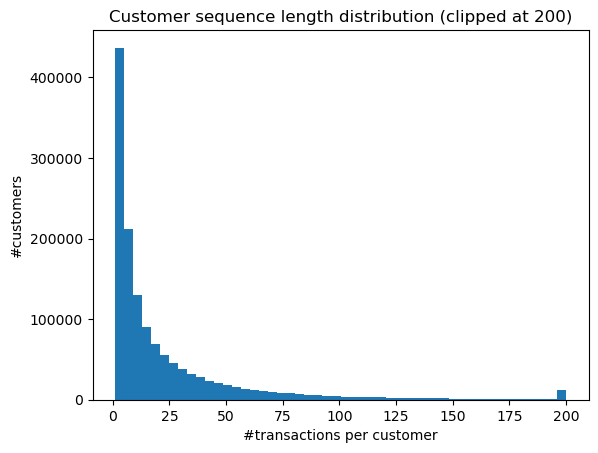

In [16]:
# item2vec EDA
seq_len =trans.groupby("customer_id").size()

seq_len.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
plt.figure()
plt.hist(np.clip(seq_len.values, 0, 200), bins=50)
plt.title("Customer sequence length distribution (clipped at 200)")
plt.xlabel("#transactions per customer")
plt.ylabel("#customers")
plt.show()

Why: If most customers have only 1–2 purchases, Item2Vec will have limited personalized context and we may rely more on popularity fallback and/or content-based (TF-IDF) similarity.Customer histories are highly skewed: most customers have few transactions, while a minority are highly active. To obtain stable embeddings under this sparsity, we (i) filter rare items via min_count (or restrict to top-K items), (ii) train on recent time windows to reduce drift, and (iii) treat purchases within a short time range (e.g., same week) as context to increase co-occurrence signal.

In [18]:
item_cnt = transactions["article_id"].value_counts()

item_cnt.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
for thr in [2, 5, 10, 20, 50]:
    print(f"min_count >= {thr}: fraction of items kept = {(item_cnt >= thr).mean():.3f}")

NameError: name 'transactions' is not defined

In [ ]:
transactions["week"] = transactions["t_dat"].dt.to_period("W")
weekly_items = transactions.groupby("week")["article_id"].nunique()
weekly_tx = transactions.groupby("week").size()

weekly_items.describe(), weekly_tx.describe()

In [ ]:
# itemcf EDA
#Interaction Sparsity
user_cnt = trans.groupby('customer_id').size()
print(user_cnt.describe(percentiles=[.5,.9,.95,.99]))

In [ ]:
item_cnt = trans.groupby('article_id').size()
print(item_cnt.describe(percentiles=[.5,.9,.95,.99]))

In [ ]:
for thr in [2,5,10,20]:
    print(thr,"fraction of items with count >= thr:",(item_cnt >= thr).mean())

WHY:
Implicit interactions are sparse and long-tailed, motivating top-K pruning and minimum-frequency filtering for stable ItemCF similarities.
We restrict similarity computation to items with sufficient interactions to reduce noise; extremely rare items produce unreliable neighbors.

### G Motivation & Feasibility

### Overall motivation
Our EDA suggests the H&M transaction data is highly sparse and long-tailed: most customers have short purchase histories, while item popularity is concentrated among a small fraction of products. A popularity-only baseline provides limited candidate coverage (e.g., even top-5k popular items only cover a minority of users with ≥1 hit), motivating additional personalized candidate-generation methods. We therefore study three complementary approaches: content-based TF-IDF, interaction-based item2vec embeddings, and an external collaborative filtering method (ItemCF). Our feasibility goal is to ensure each method is computationally tractable and can be evaluated using time-based validation with MAP@12 and candidate coverage.

---

### RQ1 (Course): Item2Vec / Word2Vec embeddings
**Motivation:** Customer histories are skewed: many users have few transactions, but the dataset includes a large number of users and repeated co-occurrence structure at scale. This motivates learning item embeddings from co-occurrence/context to capture “similar/compatible items” beyond global popularity.

**Non-triviality:** Pure popularity ignores personalization and local co-occurrence structure. Item2Vec can capture distributional similarity (items that appear in similar contexts) that is not explicitly encoded by metadata alone.

**Feasibility:** Training is feasible by (i) defining context using customer-week baskets or short windows to increase co-occurrence signal, and (ii) filtering rare items via `min_count` (e.g., 10–20) to obtain stable embeddings. We will run small pilot trainings to verify runtime and inspect nearest neighbors for sanity.

**Risks & mitigations:** Embeddings for rare items may be noisy; we mitigate by using `min_count`/top-K vocabulary and falling back to TF-IDF/popularity for cold items and very sparse users.

---

### RQ2 (Course): TF-IDF item similarity from article metadata
**Motivation:** Article metadata fields (e.g., product type, department, index group, color group) are complete (0% missingness in our checks), enabling a content-based similarity model that can generalize to cold-start items.

**Non-triviality:** Interaction-only methods may struggle for cold items or sparse users. TF-IDF provides an orthogonal signal based on item attributes, improving diversity and robustness.

**Feasibility:** The TF-IDF matrix is small and efficient (e.g., shape ≈ (105,542 items, 248 features) in our initial run), so computing item vectors and retrieving neighbors is computationally tractable.

**Risks & mitigations:** Metadata-only TF-IDF may be too coarse (limited vocabulary), leading to many ties/low discrimination. We mitigate by (i) adding field prefixes (e.g., `pt=`, `dep=`) and/or adding additional metadata fields, and (ii) tuning `min_df`, `max_features`, and top-K neighbor size.

---

### RQ3 (External): ItemCF (item-based collaborative filtering)
**Motivation:** A popularity-only candidate set has limited validation coverage (users with ≥1 hit remains low even for large K), suggesting the need for interaction-based personalization. ItemCF leverages “users who bought X also bought Y” signals directly from the implicit user–item matrix.

**Non-triviality:** Unlike TF-IDF (content) and item2vec (embedding), ItemCF explicitly models co-interaction similarity in the user–item space and often provides strong recall in retail recommenders.

**Feasibility:** ItemCF can be implemented efficiently with sparse matrices and cosine similarity, using practical constraints such as top-K item vocabulary, top-K neighbors per item, and recent-history seeding. We will validate feasibility via candidate coverage improvements over popularity baselines.

**Risks & mitigations:** Computing full item–item similarity can be expensive at full scale. We mitigate by restricting to frequent items, using approximate/top-K neighbor computation, and storing only top-K similarities per item.

### H Methodological Planning


#### 0) Validation protocol (shared across all RQs)
- **Time-based split:** Train on earlier weeks and validate on the last N weeks to avoid leakage.
- **Ground truth:** For each user in validation, the target set is the set of items purchased during the validation window.
- **Metrics:** MAP@12 (primary), recall@12, and candidate coverage (feasibility diagnostic).

**Why:** The Kaggle task is next-item recommendation with strong temporal drift; random splits would leak future interactions.

---

#### 1) Baseline: Popularity candidates
- **Method:** Recommend top-K most purchased items in the training window (global or recent).
- **Hyperparameters to sweep:** K ∈ {500, 1000, 2000, 5000, 10000}
- **Outputs:** candidate coverage, recall@12, MAP@12.

**Why:** Popularity is a strong retail baseline and provides a fallback for sparse users.

---

#### 2) TF-IDF candidate generation (Course)
- **Item representation:** Build `pseudo_text` from `articles` metadata (e.g., product type, department, index group, color group), optionally with field prefixes to reduce token collisions.
- **Model:** `TfidfVectorizer(min_df, max_features, ngram_range)` fit on all items.
- **Retrieval:** For each user, use the most recent N purchased items as seeds; retrieve top-K nearest neighbors by cosine similarity; union + de-dup.

**Planned sweeps (initial runs):**
- `min_df` ∈ {2, 5, 10}
- neighbors K ∈ {50, 100, 200}
- seed history length N ∈ {1, 3, 5}

**Why:** These choices trade off noise reduction, vocabulary size, and candidate coverage.

---

#### 3) Item2Vec candidate generation (Course)
- **Training data:** Build sequences per customer (chronological). Optionally collapse into customer-week baskets to increase co-occurrence signal.
- **Model:** Word2Vec/item2vec (Skip-gram or CBOW) with negative sampling.
- **Retrieval:** For each seed item (recent purchases), retrieve top-K nearest neighbors by cosine similarity; union + de-dup.

**Planned sweeps (initial runs):**
- `min_count` ∈ {10, 20}
- `vector_size` ∈ {32, 64}
- `window` ∈ {5, 10} (or basket-based context)
- neighbors K ∈ {50, 100}

**Why:** EDA shows many customers have short histories; filtering rare items and using basket context improves stability.

---

#### 4) ItemCF candidate generation (External)
- **Interaction matrix:** Build sparse user–item implicit matrix from training transactions.
- **Similarity:** Item–item cosine similarity (optionally shrinkage / top-K truncation).
- **Retrieval:** For each user, use their most recent N items as seeds and expand by top-K similar items per seed.

**Planned sweeps (initial runs):**
- item vocabulary restriction: top-M items by frequency (e.g., M ∈ {20k, 50k})
- item neighbors K ∈ {50, 100, 200}
- seed history length N ∈ {1, 3, 5}

**Why:** Full item–item similarity can be expensive; top-M and top-K pruning ensures tractability.

---

#### 5) Candidate pooling + scoring to produce the final Top-12
- **Pooling:** Union of candidates from popularity + TF-IDF + item2vec + ItemCF (de-dup).
- **Scoring (no learned ranker):** Weighted score fusion using normalized component scores:
  - popularity score
  - TF-IDF cosine similarity score
  - item2vec cosine similarity score
  - ItemCF similarity score
  - optional recency weight for seed item
- **Selection:** Sort candidates by final score and output top 12 per user.

**Why:** This produces a clear, interpretable pipeline aligned with the Kaggle submission format, while keeping complexity manageable.

---

#### 6) Feasibility checkpoints (must pass before full runs)
- Candidate coverage on validation should exceed the popularity-only baseline.
- Runtime/memory checks on pilot subsets (recent weeks / top-M items) before scaling up.
- Sanity checks: neighbor lists for TF-IDF/item2vec/ItemCF should be category-coherent.


### I Initial methods run

In [25]:
import pandas as pd
import numpy as np
from tqdm import tqdm 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

path = 'data/'
art = f'{path}articles.csv'
cus = f'{path}customers.csv'
train = f'{path}transactions_train.csv'
sub = f'{path}sample_submission.csv'
transactions = pd.read_csv(train)
articles = pd.read_csv(art)

In [36]:
# 1) Load + time-based split

transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])
transactions["week"] = transactions["t_dat"].dt.to_period("W")  # keep Period for correct ordering

# WHY: Kaggle test has no labels, so we create a time-based validation split to avoid leakage.
N_VALID_WEEKS = 2
weeks_sorted = np.sort(transactions["week"].unique())
valid_weeks = set(weeks_sorted[-N_VALID_WEEKS:])

train_tx = transactions[~transactions["week"].isin(valid_weeks)].copy()
valid_tx = transactions[transactions["week"].isin(valid_weeks)].copy()

print("Valid weeks:", sorted(list(valid_weeks)))
print("train rows:", len(train_tx), "valid rows:", len(valid_tx))

# ground truth: items purchased in valid window per user
user_true = valid_tx.groupby("customer_id")["article_id"].apply(lambda s: set(s)).to_dict()
valid_users = list(user_true.keys())

# popularity fallback / baseline (WHY: strong retail baseline + cold-start fallback)
POP_K = 5000
popular_items = train_tx["article_id"].value_counts().head(POP_K).index.to_list()

# 2) Sample validation users (fast pilot)

# WHY: checkpoint requires feasibility runs; sampling keeps runtime manageable.
SAMPLE_USERS = 20000
rng = np.random.default_rng(42)

valid_users_sample = rng.choice(
    valid_users,
    size=min(SAMPLE_USERS, len(valid_users)),
    replace=False).tolist()

user_true_sample = {u: user_true[u] for u in valid_users_sample}

print("Pilot valid users:", len(valid_users_sample))

# 3) TF-IDF item representation

#tfidf_fields = ["product_type_name", "department_name", "index_group_name", "colour_group_name"]
tfidf_fields = ["detail_desc"]
art = articles[["article_id"] + tfidf_fields].copy()

# WHY: prefixes reduce token collisions across different metadata fields
#art["pseudo_text"] = ("pt="  + art["product_type_name"].astype(str) + " " +"dep=" + art["department_name"].astype(str)   + " " +
#"idx=" + art["index_group_name"].astype(str)  + " " +
#"col=" + art["colour_group_name"].astype(str))
art["pseudo_text"] = "pt="  + art["detail_desc"].astype(str) 
# WHY: min_df filters rare/noisy tokens; max_features prevents runaway vocabulary size
vec = TfidfVectorizer(min_df=5, max_features=200000)
X = vec.fit_transform(art["pseudo_text"])

# cosine neighbor search (brute is OK for TF-IDF sparse vectors; we sample users to keep it fast)
nn = NearestNeighbors(metric="cosine", algorithm="brute")
nn.fit(X)

idx_to_aid = art["article_id"].to_numpy()
aid_to_idx = pd.Series(np.arange(len(art)), index=art["article_id"]).to_dict()

# 4) Recent seed items from TRAIN only (no leakage)

N_SEEDS = 3
train_sorted = train_tx.sort_values(["customer_id", "t_dat"])
user_seeds = train_sorted.groupby("customer_id")["article_id"].apply(lambda s: list(s)[-N_SEEDS:]).to_dict()

# -----------------------------
# 5) Metrics
# -----------------------------
def apk(actual_set, pred_list, k=12):
    if not actual_set:
        return 0.0
    pred_list = pred_list[:k]
    hits = 0
    score = 0.0
    for i, p in enumerate(pred_list, start=1):
        if p in actual_set:
            hits += 1
            score += hits / i
    return score / min(len(actual_set), k)

def mapk(user_true_dict, user_pred_dict, k=12):
    return float(np.mean([apk(user_true_dict[u], user_pred_dict.get(u, []), k) for u in user_true_dict]))

def recall_at_k(actual_set, pred_list, k=12):
    if not actual_set:
        return 0.0
    return len(set(pred_list[:k]) & actual_set) / len(actual_set)

def mean_recall_k(user_true_dict, user_pred_dict, k=12):
    return float(np.mean([recall_at_k(user_true_dict[u], user_pred_dict.get(u, []), k) for u in user_true_dict]))

def candidate_coverage(user_true_dict, user_cand_dict):
    cov = []
    any_hit = []
    for u, true_set in user_true_dict.items():
        cand_set = user_cand_dict.get(u, set())
        if not true_set:
            continue
        cov.append(len(true_set & cand_set) / len(true_set))
        any_hit.append(1.0 if len(true_set & cand_set) > 0 else 0.0)
    return float(np.mean(cov)), float(np.mean(any_hit))

# quick non-trivial test
assert abs(apk({1, 2}, [1, 3, 2], 12) - ((1/1 + 2/3)/2)) < 1e-9

# -----------------------------
# 6) TF-IDF candidate generation + evaluation
# -----------------------------
TOPK_PER_SEED = 50

def tfidf_rank_for_user(customer_id):
    seeds = user_seeds.get(customer_id, [])
    scores = {}

    for aid in seeds:
        j = aid_to_idx.get(aid)
        if j is None:
            continue

        # retrieve neighbors for this seed item
        dists, nbr_idx = nn.kneighbors(X[j], n_neighbors=TOPK_PER_SEED + 1)
        for dist, ni in zip(dists[0], nbr_idx[0]):
            nb_aid = int(idx_to_aid[ni])
            if nb_aid == int(aid):
                continue
            sim = 1.0 - float(dist)
            if sim > scores.get(nb_aid, -1):
                scores[nb_aid] = sim

    ranked = [aid for aid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

    # fill to 12 with popularity fallback for fair MAP@12 comparison
    if len(ranked) < 12:
        for a in popular_items:
            if a not in scores:
                ranked.append(a)
            if len(ranked) == 12:
                break

    return ranked[:12], set(scores.keys())

pred_ranked = {}
pred_cands = {}

for u in tqdm(valid_users_sample, desc="TF-IDF eval (sample users)"):
    ranked12, cand_set = tfidf_rank_for_user(u)
    pred_ranked[u] = ranked12
    pred_cands[u] = cand_set

cov_mean, users_hit = candidate_coverage(user_true_sample, pred_cands)
print("TF-IDF candidate coverage (mean per-user):", cov_mean)
print("TF-IDF users with >=1 hit:", users_hit)
print("TF-IDF MAP@12:", mapk(user_true_sample, pred_ranked, k=12))
print("TF-IDF Recall@12:", mean_recall_k(user_true_sample, pred_ranked, k=12))

Valid weeks: [Period('2020-09-14/2020-09-20', 'W-SUN'), Period('2020-09-21/2020-09-27', 'W-SUN')]
train rows: 31492019 valid rows: 296305
Pilot valid users: 20000


TF-IDF eval (sample users): 100%|█████████| 20000/20000 [08:34<00:00, 38.90it/s]


TF-IDF candidate coverage (mean per-user): 0.033890866504880185
TF-IDF users with >=1 hit: 0.06915
TF-IDF MAP@12: 0.004856789358749315
TF-IDF Recall@12: 0.013789979342975033


In [40]:
pop12 = popular_items[:12]
pred_pop = {u: pop12 for u in valid_users_sample}

print("POP MAP@12:", mapk(user_true_sample, pred_pop, k=12))
print("POP Recall@12:", mean_recall_k(user_true_sample, pred_pop, k=12))

POP MAP@12: 0.002843765737148854
POP Recall@12: 0.007855953366911353


### I.1 TF-IDF (Content-based item similarity)

### What the code does
- Builds an **item “pseudo-text”** for each `article_id` using metadata fields from `articles.csv` (e.g., product type, department, index group, color group).
- Fits a **TF-IDF vectorizer** on all items to obtain a sparse matrix `X` where each row is an item and each column is a token/feature.
- Uses **cosine nearest neighbors** to retrieve the top-K most similar items for a user’s **recently purchased seed items** (derived from the training split only).
- Produces a ranked top-12 list per user by sorting items by cosine similarity, then **fills to 12 with popularity** as a fallback.
- Evaluates on a **time-based validation split** (sampled users) using candidate coverage, MAP@12, and Recall@12.

### Why 
- **Why use `articles` metadata:** It provides a pure content signal that can generalize to items even when interaction signals are sparse; it also supports interpretability (neighbors share attributes).
- **Why “pseudo-text” + TF-IDF:** TF-IDF is a simple, well-understood representation for weighted categorical/text tokens and is computationally efficient for large item catalogs.
- **Why add field prefixes (e.g., `pt=`, `dep=`):** Prevents token collisions where the same string could appear in different fields, improving semantic clarity.
- **Why cosine similarity + top-K neighbors:** Cosine is standard for TF-IDF vectors; top-K keeps candidate generation tractable.
- **Why seeds come only from train:** Prevents leakage; we simulate real-world prediction where future purchases are unknown.
- **Why popularity fallback:** Some users have no training history (cold-start) or some seed items may not yield neighbors; fallback ensures every user has 12 predictions and provides a strong retail baseline.

In [5]:
# -----------------------------
# Item2Vec (Word2Vec on items) + evaluation on sampled valid users
# -----------------------------
from gensim.models import Word2Vec
from tqdm import tqdm

# ---- 1) Build training "sentences" from TRAIN only (no leakage)
# WHY: many users have short sequences; using customer-week baskets increases co-occurrence signal.
tmp = train_tx.copy()
tmp["week_str"] = tmp["week"].astype(str)

sentences = (
    tmp.groupby(["customer_id", "week_str"])["article_id"]
      .apply(lambda s: [str(x) for x in s.unique()])
      .tolist()
)

print("Num baskets (sentences):", len(sentences))

# ---- 2) Train item2vec
# WHY: min_count filters rare items to get more stable embeddings; skip-gram works well for sparse data.
w2v = Word2Vec(
    sentences=sentences,
    vector_size=64,
    window=5,
    min_count=10,
    sg=1,
    negative=10,
    workers=4,
    epochs=5
)

# ---- 3) Candidate generation from recent seeds + evaluation
TOPK_PER_SEED = 50  # same idea as TF-IDF
N_PRED = 12

def item2vec_rank_for_user(customer_id):
    seeds = user_seeds.get(customer_id, [])
    scores = {}

    for aid in seeds:
        key = str(aid)
        if key not in w2v.wv:
            continue
        for nb_key, sim in w2v.wv.most_similar(key, topn=TOPK_PER_SEED):
            nb_aid = int(nb_key)
            if nb_aid == int(aid):
                continue
            if sim > scores.get(nb_aid, -1):
                scores[nb_aid] = float(sim)

    ranked = [aid for aid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

    # fill to 12 with popularity fallback for fair MAP@12 comparison (same as TF-IDF)
    if len(ranked) < N_PRED:
        for a in popular_items:
            if a not in scores:
                ranked.append(a)
            if len(ranked) == N_PRED:
                break

    return ranked[:N_PRED], set(scores.keys())

pred_ranked_i2v = {}
pred_cands_i2v = {}

for u in tqdm(valid_users_sample, desc="Item2Vec eval (sample users)"):
    ranked12, cand_set = item2vec_rank_for_user(u)
    pred_ranked_i2v[u] = ranked12
    pred_cands_i2v[u] = cand_set

cov_mean, users_hit = candidate_coverage(user_true_sample, pred_cands_i2v)
print("Item2Vec candidate coverage (mean per-user):", cov_mean)
print("Item2Vec users with >=1 hit:", users_hit)
print("Item2Vec MAP@12:", mapk(user_true_sample, pred_ranked_i2v, k=12))
print("Item2Vec Recall@12:", mean_recall_k(user_true_sample, pred_ranked_i2v, k=12))

Num baskets (sentences): 8001690


Item2Vec eval (sample users): 100%|██████| 20000/20000 [01:20<00:00, 247.74it/s]


Item2Vec candidate coverage (mean per-user): 0.045718128798398414
Item2Vec users with >=1 hit: 0.0983
Item2Vec MAP@12: 0.0054503346088435375
Item2Vec Recall@12: 0.012921588239315947


### I.2 Item2Vec (Word2Vec embeddings on items)

### What the code does
- Constructs **training “sentences”** from the transaction data using **customer-week baskets**: each (customer, week) basket becomes a list of item tokens.
- Trains a **Word2Vec model** (Item2Vec) where each `article_id` is treated as a “word”, producing dense item embeddings.
- For each user, takes the **most recent N seed items** from the training split and retrieves top-K **most similar items** in the embedding space (`most_similar`).
- Produces a ranked top-12 recommendation list (embedding similarity ranking) and applies **popularity fallback** if fewer than 12 items are retrieved.
- Evaluates on the same time-based validation sample using candidate coverage, MAP@12, and Recall@12.

### Why these choices
- **Why customer-week baskets:** Many customers have short sequential histories; basket-level co-occurrence increases usable context and improves embedding stability.
- **Why Skip-gram (`sg=1`):** Skip-gram tends to work better with sparse data and rare tokens compared to CBOW.
- **Why `min_count` filtering:** Embeddings for extremely rare items are noisy; filtering improves stability and reduces training noise.
- **Why use embedding neighbors for candidate expansion:** Item2Vec captures distributional similarity (“items appearing in similar contexts”), complementing popularity and content-based signals.
- **Why popularity fallback:** Handles cold-start users/items and guarantees a fixed top-12 output for evaluation and submission formatting.

In [7]:
import math
from collections import defaultdict
from tqdm import tqdm
import pandas as pd
import numpy as np

# -----------------------------
# ItemCF params 
# -----------------------------
TOP_K = 12
MAX_USER_ITEMS = 20
ITEM_SIM_TOPK = 100

def time_decay(delta_days: int) -> float:
    # WHY: recent co-occurrence is more relevant (retail drift)
    return math.exp(-delta_days / 30)

# -----------------------------
# 1) 
# -----------------------------

START_DATE = (train_tx["t_dat"].max() - pd.Timedelta(days=90)).date().isoformat()
# START_DATE = "2020-08-21"  #

df_small = train_tx[train_tx["t_dat"] > pd.to_datetime(START_DATE)].copy()

# -----------------------------
# 2) for every user only keep MAX_USER_ITEMS actions(avoid leakage only train）
# -----------------------------
user_item_time = (
    df_small.sort_values("t_dat")
    .groupby("customer_id")[["article_id", "t_dat"]]
    .apply(lambda x: list(zip(x["article_id"].astype(int), x["t_dat"]))[-MAX_USER_ITEMS:])
    .to_dict()
)

print("START_DATE:", START_DATE)
print("Users with histories in window:", len(user_item_time))

# -----------------------------
# 3) ItemCF sim：time decay + position + normalization + topK truncate
# -----------------------------
item_sim = defaultdict(lambda: defaultdict(float))
item_cnt = defaultdict(int)

for user, item_time_list in tqdm(user_item_time.items(), desc="Build ItemCF"):
    items = [i for i, _ in item_time_list]
    times = [t for _, t in item_time_list]
    L = len(items)
    if L <= 1:
        continue

    for i in range(L):
        item_i = items[i]
        time_i = times[i]
        item_cnt[item_i] += 1

        for j in range(L):
            if i == j:
                continue
            item_j = items[j]
            time_j = times[j]

            delta = abs((time_i - time_j).days)

            # location:more recent more important
            loc_weight = 1.0 / (1.0 + abs(i - j))

            item_sim[item_i][item_j] += loc_weight * time_decay(delta)

# normalization（cosine-like）
for i, related in item_sim.items():
    for j in list(related.keys()):
        related[j] /= math.sqrt(item_cnt[i] * item_cnt[j])

# topK truncated
item_sim_topk = {}
for i, related in item_sim.items():
    item_sim_topk[i] = dict(sorted(related.items(), key=lambda x: x[1], reverse=True)[:ITEM_SIM_TOPK])
item_sim = item_sim_topk

print("Items with neighbors:", len(item_sim))

# -----------------------------
# 4) recall func：recent items accumulated similarity
# -----------------------------
def itemcf_recall(user_items, item_sim, topk=TOP_K):
    scores = defaultdict(float)
    for item in user_items:
        if item not in item_sim:
            continue
        for j, sim in item_sim[item].items():
            scores[j] += sim
    ranked = [i for i, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]
    return ranked, set(scores.keys())

# -----------------------------
# 5)validate on sampled valid users coverage / MAP@12 / Recall@12）
# -----------------------------
pred_ranked_icf = {}
pred_cands_icf = {}

for cust in tqdm(valid_users_sample, desc="ItemCF eval (sample users)"):

    if cust in user_item_time:
        user_items = [i for i, _ in user_item_time[cust]]
        ranked, cand_set = itemcf_recall(user_items, item_sim, topk=1000)  
    else:
        ranked, cand_set = [], set()

    # create top-12，use popularity
    rec12 = []
    for a in ranked:
        if a not in rec12:
            rec12.append(a)
        if len(rec12) == TOP_K:
            break

    if len(rec12) < TOP_K:
        for a in popular_items:
            if a not in rec12:
                rec12.append(a)
            if len(rec12) == TOP_K:
                break

    pred_ranked_icf[cust] = rec12
    pred_cands_icf[cust] = cand_set  # only ItemCF candidates（no pop）

cov_mean, users_hit = candidate_coverage(user_true_sample, pred_cands_icf)
print("ItemCF candidate coverage (mean per-user):", cov_mean)
print("ItemCF users with >=1 hit:", users_hit)
print("ItemCF MAP@12:", mapk(user_true_sample, pred_ranked_icf, k=12))
print("ItemCF Recall@12:", mean_recall_k(user_true_sample, pred_ranked_icf, k=12))

START_DATE: 2020-06-15
Users with histories in window: 539054


Build ItemCF: 100%|██████████████████| 539054/539054 [00:37<00:00, 14362.93it/s]


Items with neighbors: 41412


ItemCF eval (sample users): 100%|███████| 20000/20000 [00:03<00:00, 5833.27it/s]

ItemCF candidate coverage (mean per-user): 0.12915145591572372
ItemCF users with >=1 hit: 0.23075
ItemCF MAP@12: 0.01815842614384673
ItemCF Recall@12: 0.04149484250097287


### I.3 ItemCF (External: Item-based collaborative filtering with time/position weighting)

### What the code does
- Uses only the **training split** transactions and (optionally) restricts to a **recent time window** to reduce concept drift and speed up computation.
- For each user, keeps only their **most recent MAX_USER_ITEMS** interactions to limit noise and control runtime.
- Builds an **item–item similarity dictionary** by iterating over each user’s item list and accumulating co-occurrence contributions:
  - Applies **time decay** based on the day difference between two interactions.
  - Applies a **position (distance) weight** so items closer in the user’s history contribute more.
- Normalizes similarity scores by item frequencies (cosine-like normalization) and keeps only the **top ITEM_SIM_TOPK neighbors** per item.
- Generates recommendations by scoring candidate items as the **sum of similarities** from the user’s recent items, then returns top-12 with **popularity fallback**.
- Evaluates on the time-based validation sample using candidate coverage, MAP@12, and Recall@12.

### Why these choices
- **Why ItemCF as external:** It is a collaborative filtering method based on the implicit user–item matrix, distinct from course-style TF-IDF and embedding methods.
- **Why recent time window:** Fashion demand drifts; recent co-interactions are more predictive and also reduce computation.
- **Why cap user history (`MAX_USER_ITEMS`):** Long histories include outdated preferences; limiting to recent actions focuses on short-term intent and speeds up similarity construction.
- **Why time decay:** Encourages co-occurrences closer in time to contribute more, matching recency effects in retail.
- **Why position weight:** Interactions closer together in a user’s sequence are more likely to reflect the same shopping mission/context.
- **Why top-K neighbor truncation:** Prevents the similarity graph from becoming too dense and keeps retrieval efficient.
- **Why popularity fallback:** Ensures coverage for cold-start users and provides a strong, simple default when CF signals are unavailable.

### Comparison

In [9]:
results = [
    ("POP@12", None, None, 0.002843765737148854, 0.007855953366911353),
    ("TF-IDF", 0.017098070893396967, 0.04105, 0.000642187981000481, 0.002381236631016043),
    ("Item2Vec", 0.045718128798398414, 0.0983, 0.0054503346088435375, 0.012921588239315947),
    ("ItemCF", 0.12915145591572372, 0.23075, 0.01815842614384673, 0.04149484250097287),
]
pd.DataFrame(results, columns=["Method", "CandCoverageMean", "Users>=1Hit", "MAP@12", "Recall@12"])

,Method,CandCoverageMean,Users>=1Hit,MAP@12,Recall@12
0,POP@12,NaN,NaN,0.002844,0.007856
1,TF-IDF,0.017098,0.04105,0.000642,0.002381
2,Item2Vec,0.045718,0.09830,0.005450,0.012922
3,ItemCF,0.129151,0.23075,0.018158,0.041495


### J Assumptions 

Below are the main assumptions each method makes about the data and user behavior. These assumptions justify when the method should work well and also clarify potential failure modes.


#### TF-IDF (content-based item similarity)

- Metadata similarity reflects substitution/compatibility. 
Items with similar article attributes (e.g., product type, department, color group) are assumed to be reasonable recommendations for each other.

- Article metadata is accurate and sufficiently informative.
The selected fields are assumed to be clean, consistent, and discriminative enough to separate meaningful item groups.

- User intent can be approximated by recent purchases.
A user’s next purchase is assumed to be related to their most recent N purchased items (used as seeds).

- Cosine similarity over TF-IDF vectors is a valid similarity proxy.
Cosine similarity is assumed to capture “closeness” in attribute space for retrieval.

**Where this can break:** If metadata is too coarse (many items share the same attributes) or user behavior is driven by trends/promotions not encoded in metadata, TF-IDF neighbors may not match future purchases.

#### Item2Vec (Word2Vec embeddings on items)

- Co-occurrence implies semantic similarity. 
Items that appear in similar shopping contexts (co-purchased within a basket/window) are assumed to be functionally similar or complementary.

- Basket/window context is a meaningful approximation.  
Treating customer-week baskets as “sentences” assumes that items bought within the same week reflect a coherent shopping intent/context.

- Stationarity within the training window.
The learned embedding space assumes that co-occurrence structure is reasonably stable within the chosen training period (or recent window).

- Sufficient frequency for stable vectors.
Items below `min_count` are assumed too rare to learn reliable embeddings; embeddings are assumed meaningful primarily for items with enough interactions.

**Where this can break:** If many users have extremely sparse histories or if demand shifts strongly over time, embeddings may be noisy or misaligned with validation/test behavior.

#### ItemCF (item-based collaborative filtering with time/position weighting)

- “Users who bought X also bought Y” generalizes.
The main CF assumption: co-interactions encode preference similarity and can predict future purchases.

- Recent interactions are more predictive (recency).
Time decay assumes that more recent co-occurrence relationships better reflect current user intent and current catalog trends.

-  Local proximity in the sequence reflects shared intent.
The position weight assumes items closer together in a user’s recent history belong to the same shopping mission and should contribute more.

- Implicit feedback is adequate. 
Using purchases as binary/implicit signals assumes that purchases reflect positive preference without explicit negatives.

- Truncation preserves the important signal.
Keeping only the most recent `MAX_USER_ITEMS` and top-K neighbors per item assumes the most relevant signal is retained while noise and computation are reduced.

**Where this can break:** Cold-start users/items (no history), very rare items (no reliable neighbors), or extreme concept drift can reduce CF reliability; popularity fallback mitigates this.
